In [78]:
from ucimlrepo import fetch_ucirepo 

In [79]:
connectionist_bench_sonar_mines_vs_rocks = fetch_ucirepo(id=151) 

In [80]:
X = connectionist_bench_sonar_mines_vs_rocks.data.features 
y = connectionist_bench_sonar_mines_vs_rocks.data.targets 

In [109]:
X.shape, y.shape # Number of features for CNN input (60)

((208, 60), (208, 1))

In [91]:
label_map = {"M": 1, "R": 0}
y_con = y["class"].map(label_map)

In [179]:
# Core 

import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Data Manipulation and Cleaning

import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Model Evaluation 

from sklearn.metrics import confusion_matrix, classification_report 

# Data Visualization 

import matplotlib.pyplot as plt 
import seaborn as sns 

In [180]:
X_np = X.to_numpy()
y_np = y_con.to_numpy()

In [181]:
X_t = torch.from_numpy(X_np).type(torch.float)
y_t = torch.from_numpy(y_np).type(torch.float)

X_t.shape, y_t.shape

(torch.Size([208, 60]), torch.Size([208]))

In [182]:
X_t.dtype

torch.float32

In [183]:
y_t.dtype 

torch.float32

In [184]:
# Use the tensors for train test split

x_train, x_test, y_train, y_test = train_test_split(X_t, y_t, test_size = 0.2, random_state=42)

In [185]:
len(x_train), len(x_test), len(y_train), len(y_test)

(166, 42, 166, 42)

In [186]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [219]:
class SonarModel(nn.Module): 
    def __init__(self): 
        super().__init__() 
        self.network = nn.Sequential(
           nn.Linear(60,128),
           nn.ReLU(),
           nn.Dropout(0.2),
           nn.Linear(128,64),
           nn.ReLU(),
           nn.Dropout(0.2),
           nn.Linear(64,1),

        )
        
    
    def forward(self, x): 
        return self.network(x)


Model0 = SonarModel().to(device)
Model0

SonarModel(
  (network): Sequential(
    (0): Linear(in_features=60, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [220]:
untrained_preds = Model0(x_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 42, Shape: torch.Size([42, 1])
Length of test samples: 42, Shape: torch.Size([42])

First 10 predictions:
tensor([[0.1540],
        [0.1445],
        [0.1104],
        [0.1370],
        [0.1117],
        [0.0865],
        [0.0580],
        [0.1201],
        [0.1779],
        [0.0739]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 0., 0., 1., 0., 1., 1., 0., 1.])


In [221]:
# Build the loss function 
loss_fcn = nn.BCEWithLogitsLoss()

# Optimizer

optimizer = optim.Adam(params=Model0.parameters(), lr=0.0005)

In [222]:
def accuracy_score(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_pred)) * 100
    return acc 


In [ ]:
torch.manual_seed(42)

epochs = 300

x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

for epoch in range(epochs): 

    Model0.train()

    y_logits = Model0(x_train).squeeze(1)
    y_pred = torch.round(torch.sigmoid(y_logits))

    # loss function

    loss = loss_fcn(y_logits, y_train)

    # accuracy 

    acc = accuracy_score(y_train, y_pred)

    # optimizer zero grad

    optimizer.zero_grad()

    # backpropagation

    loss.backward()

    # optimizer step

    optimizer.step()

    ## testing

    Model0.eval()

    with torch.inference_mode():
        test_logits = Model0(x_test).squeeze(1)
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fcn(test_logits, y_test.float())
        test_acc = accuracy_score(y_true=y_test, y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.43800, Accuracy: 78.31% | Test loss: 0.37593, Test acc: 85.71%
Epoch: 10 | Loss: 0.41920, Accuracy: 80.72% | Test loss: 0.34951, Test acc: 90.48%
Epoch: 20 | Loss: 0.39232, Accuracy: 81.93% | Test loss: 0.32925, Test acc: 88.10%
Epoch: 30 | Loss: 0.36157, Accuracy: 86.14% | Test loss: 0.32044, Test acc: 90.48%
Epoch: 40 | Loss: 0.35247, Accuracy: 84.94% | Test loss: 0.31561, Test acc: 90.48%
Epoch: 50 | Loss: 0.34233, Accuracy: 84.34% | Test loss: 0.31455, Test acc: 88.10%
Epoch: 60 | Loss: 0.33295, Accuracy: 86.75% | Test loss: 0.31553, Test acc: 88.10%
Epoch: 70 | Loss: 0.29585, Accuracy: 86.75% | Test loss: 0.31574, Test acc: 88.10%
Epoch: 80 | Loss: 0.28526, Accuracy: 88.55% | Test loss: 0.31694, Test acc: 88.10%
Epoch: 90 | Loss: 0.28186, Accuracy: 90.36% | Test loss: 0.31435, Test acc: 88.10%
Epoch: 100 | Loss: 0.26055, Accuracy: 88.55% | Test loss: 0.30925, Test acc: 88.10%
Epoch: 110 | Loss: 0.24530, Accuracy: 92.77% | Test loss: 0.31751, Test acc: 88.10%
Epo

In [196]:
import requests

request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")

with open("helper_functions.py", "wb") as f: 
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

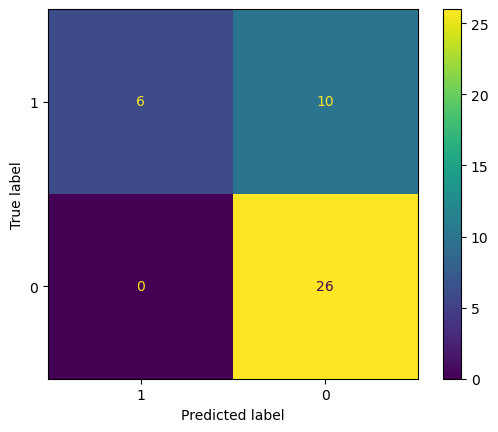

In [202]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm, display_labels=["1","0"]).plot()

In [226]:
best_loss = float('inf')
patience = 40
counter = 0

for epoch in range(epochs):
    # training code...

    if test_loss < best_loss:
        best_loss = test_loss
        torch.save(Model0.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Load the best version
Model0.load_state_dict(torch.load("best_model.pth"))

Early stopping at epoch 40


<All keys matched successfully>